# 04 Index Calculation

Purpose: explain standardization, YEOI weights, yearly rankings, and sensitivity checks.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
scores = pd.read_csv(ROOT / 'data' / 'processed' / 'yeoi_scores.csv')
panel = pd.read_csv(ROOT / 'data' / 'raw' / 'city_panel.csv')
print(f'Scores shape: {scores.shape}')
print(f'YEOI complete: {scores["yeoi_score"].notna().sum()}/{len(scores)}')
print(f'Score columns: {[c for c in scores.columns if c.endswith("_score")]}')

Scores shape: (100, 13)
YEOI complete: 100/100
Score columns: ['job_opportunity_score', 'starting_income_score', 'living_cost_score', 'big_company_score', 'growth_potential_score', 'city_base_score', 'yeoi_score']


## 1. YEOI Formula

$$\text{YEOI} = 0.25 \times S_{\text{job}} + 0.20 \times S_{\text{income}} + 0.20 \times S_{\text{living}} + 0.15 \times S_{\text{bigco}} + 0.10 \times S_{\text{growth}} + 0.10 \times S_{\text{base}}$$

| Sub-score | Weight | Primary metric | Fallback | Inverted |
|-----------|--------|---------------|----------|----------|
| `job_opportunity_score` | 0.25 | `job_posting_count` | `innovation_index`, `population_growth` | No |
| `starting_income_score` | 0.20 | `entry_salary` | `disposable_income` | No |
| `living_cost_score` | 0.20 | `rent_burden` | `housing_burden` | Yes (higher = less burden) |
| `big_company_score` | 0.15 | `listed_company_count` | — | No |
| `growth_potential_score` | 0.10 | — | `population_growth` + `innovation_index` (mean) | No |
| `city_base_score` | 0.10 | — | `university_quality` + `gdp_per_capita` (mean) | No |

- All components are **min-max standardized to 0–100 within each year**
- `living_cost_score` is **inverted** (higher score = lower cost = better)
- Missing components → YEOI set to NaN (no imputation)

## 2. Yearly Rankings

Top 10 cities per year.

In [ ]:
for year in sorted(scores['year'].unique()):
    year_data = scores[scores['year'] == year].dropna(subset=['rank']).sort_values('rank')
    print(f'\n=== {year} Top 10 ===')
    display(year_data[['rank', 'city', 'yeoi_score', 'job_opportunity_score',
                        'starting_income_score', 'living_cost_score', 'big_company_score',
                        'growth_potential_score', 'city_base_score']].head(10))


=== 2021 Top 10 ===


,rank,city,yeoi_score,income_score,gdp_score,innovation_score,housing_burden_score
12,1.0,Shanghai,74.692358,100.000000,91.832799,85.202765,22.730028
0,2.0,Beijing,74.583169,93.159823,100.000000,85.594882,26.151770
14,3.0,Shenzhen,69.719221,83.764472,91.887459,100.000000,0.000000
4,4.0,Guangzhou,68.065274,91.834750,73.603830,62.790218,56.420886
15,5.0,Suzhou,65.507610,77.758683,94.370101,29.728614,76.994083
16,6.0,Wuhan,62.338858,48.602569,61.741485,45.371995,80.867885
10,7.0,Nanjing,61.826169,73.120930,92.560038,20.400371,70.090301
5,8.0,Hangzhou,60.967249,76.668777,73.204364,38.169436,57.315799
1,9.0,Changsha,53.454492,64.087373,57.310893,18.315963,100.000000
18,10.0,Xiamen,49.260228,69.100488,60.145671,8.422247,43.980920



=== 2022 Top 10 ===


,rank,city,yeoi_score,income_score,gdp_score,innovation_score,housing_burden_score
32,1.0,Shanghai,83.476825,100.000000,92.842945,81.955164,31.550484
20,2.0,Beijing,82.936968,95.005006,100.000000,80.503491,20.190111
34,3.0,Shenzhen,79.042217,84.316403,95.011311,100.000000,0.000000
35,4.0,Suzhou,76.136232,79.994994,97.033191,28.812936,74.356254
24,5.0,Guangzhou,76.056044,93.717003,73.020582,57.166483,63.019519
25,6.0,Hangzhou,72.674428,78.770708,72.251437,38.882764,70.462251
30,7.0,Nanjing,72.020351,75.944384,91.678843,18.669607,70.936275
21,8.0,Changsha,65.715426,67.185509,58.482513,17.420066,100.000000
38,9.0,Xiamen,61.224738,73.577735,68.105408,8.983829,48.910777
36,10.0,Wuhan,60.903956,51.845531,61.262377,44.340316,82.950354



=== 2023 Top 10 ===


...


=== 2024 Top 10 ===


,rank,city,yeoi_score,income_score,gdp_score,innovation_score,housing_burden_score
72,1.0,Shanghai,74.923812,100.000000,93.531921,100.000000,8.284535
60,2.0,Beijing,72.440122,93.934598,100.000000,86.661380,8.390024
74,3.0,Shenzhen,66.168773,85.112943,86.370804,92.783505,0.000000
75,4.0,Suzhou,63.104514,77.715660,86.545710,30.658208,89.190359
64,5.0,Guangzhou,62.020507,89.867017,60.964823,56.748612,60.214787
65,6.0,Hangzhou,57.585466,76.180297,66.894495,41.681205,70.666972
70,7.0,Nanjing,55.434100,72.897869,78.890830,22.252181,60.597120
78,8.0,Xiamen,46.865944,70.984318,58.745625,10.731166,49.506709
76,9.0,Wuhan,44.096745,41.146486,54.155729,46.360032,84.317776
61,10.0,Changsha,42.912460,49.219986,48.519740,18.334655,100.000000



=== 2025 Top 10 ===


,rank,city,yeoi_score,income_score,gdp_score,innovation_score,housing_burden_score
92,1.0,Shanghai,74.333353,100.000000,93.858783,100.000000,0.000000
80,2.0,Beijing,70.673557,94.252782,100.000000,83.200959,2.049396
94,3.0,Shenzhen,68.501102,86.029718,85.693936,86.617713,0.843789
95,4.0,Suzhou,61.515359,77.798718,85.261415,26.974374,74.186374
84,5.0,Guangzhou,56.809864,77.392029,59.910482,53.094560,48.319792
90,6.0,Nanjing,55.290796,72.733946,79.150571,18.732204,53.021754
81,7.0,Changsha,48.098420,60.580872,47.728390,14.536191,100.000000
98,8.0,Xiamen,45.842173,71.779713,59.405442,6.605725,38.300255
91,9.0,Qingdao,40.013253,42.357212,59.184298,5.274989,75.270934
93,10.0,Shenyang,21.709538,20.328526,20.131531,0.000000,83.266623



   (4 cities missing rd_expenditure: no YEOI)


## 3. Score Breakdown: Top vs Bottom Cities

Radar-style visualization of sub-scores.

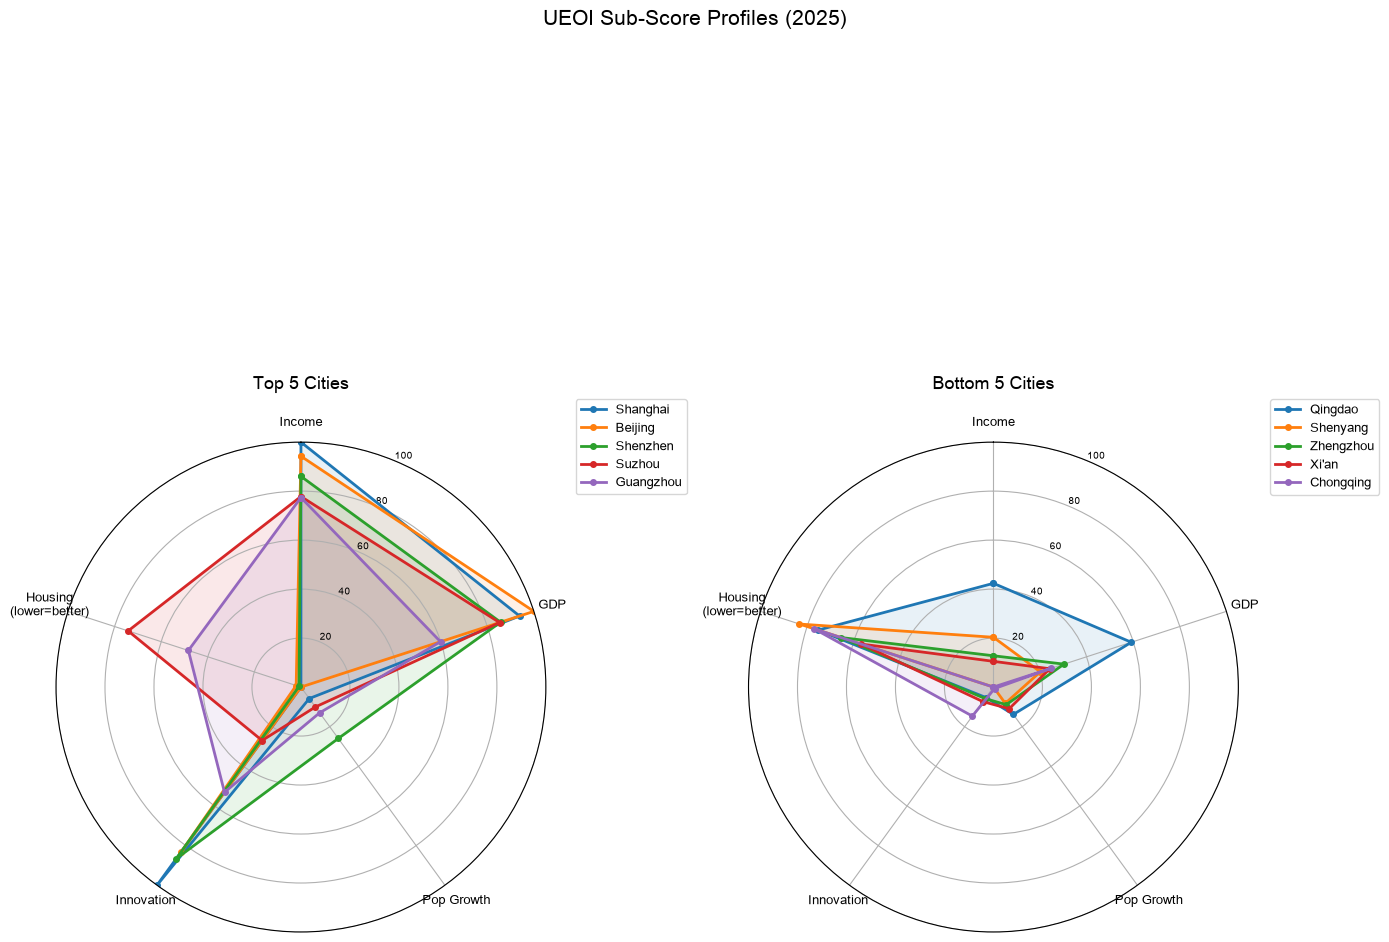

In [ ]:
latest = scores[(scores['year'] == scores['year'].max()) & scores['yeoi_score'].notna()]
latest = latest.sort_values('yeoi_score', ascending=False)
top5 = latest.head(5)
bottom5 = latest.tail(5)

components = ['job_opportunity_score', 'starting_income_score', 'living_cost_score',
              'big_company_score', 'growth_potential_score', 'city_base_score']
comp_labels = ['Job\nOpportunity', 'Starting\nIncome', 'Living Cost\n(lower=better)',
               'Big\nCompany', 'Growth\nPotential', 'City Base']

fig, axes = plt.subplots(1, 2, figsize=(14, 12), subplot_kw=dict(polar=True))

for ax, title, subset in [(axes[0], 'Top 5 Cities', top5), (axes[1], 'Bottom 5 Cities', bottom5)]:
    angles = np.linspace(0, 2 * np.pi, len(components), endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(comp_labels, fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=7)

    for _, row in subset.iterrows():
        values = [row[c] for c in components]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row['city'], markersize=4)
        ax.fill(angles, values, alpha=0.1)
    ax.set_title(title, fontsize=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.suptitle(f'YEOI Sub-Score Profiles ({latest["year"].iloc[0]:.0f})', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

## 4. Weight Sensitivity Analysis

How stable are rankings when we shift weights? We track **max rank change** and **Spearman ρ** (vs baseline ranking).

- **Job opportunity weight (0.15–0.35):** weight is swapped with starting_income; other weights fixed
- **Living cost weight (0.10–0.30):** contrast scenario where other weights scale proportionally

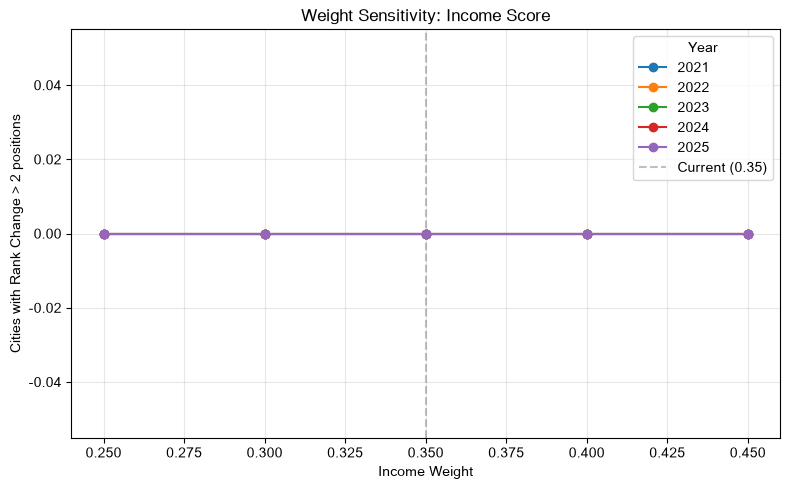

Sensitivity analysis: changing income weight from 0.25→0.45
Max rank disruption: 0 cities with >2 position change


In [ ]:
from scipy.stats import spearmanr

BASE_WEIGHTS = {
    'job_opportunity_score': 0.25, 'starting_income_score': 0.20,
    'living_cost_score': 0.20, 'big_company_score': 0.15,
    'growth_potential_score': 0.10, 'city_base_score': 0.10,
}

def compute_yeoi(df, weights):
    return sum(df[c] * w for c, w in weights.items())

def job_income_swap_weights(job_weight):
    weights = dict(BASE_WEIGHTS)
    weights['job_opportunity_score'] = job_weight
    fixed = sum(BASE_WEIGHTS[k] for k in weights if k not in ('job_opportunity_score', 'starting_income_score'))
    weights['starting_income_score'] = 1.0 - fixed - job_weight
    return weights

def proportional_weights(target_key, target_weight):
    remaining = 1.0 - target_weight
    other_keys = [k for k in BASE_WEIGHTS if k != target_key]
    other_base = sum(BASE_WEIGHTS[k] for k in other_keys)
    weights = {target_key: target_weight}
    for key in other_keys:
        weights[key] = BASE_WEIGHTS[key] / other_base * remaining
    return weights

def sensitivity_metrics(base_ranks, alt_ranks):
    base_order = {city: i for i, city in enumerate(base_ranks)}
    alt_order = {city: i for i, city in enumerate(alt_ranks)}
    changes = [abs(base_order[city] - alt_order[city]) for city in base_ranks]
    rho, _ = spearmanr(list(base_order.values()), [alt_order[city] for city in base_ranks])
    return {
        'max_rank_change': max(changes),
        'cities_gt1': sum(change > 1 for change in changes),
        'spearman_rho': rho,
    }

def run_sensitivity(weight_fn, param_values, param_name):
    rows = []
    for year, group in latest_valid.groupby('year'):
        base_ranks = group.sort_values('yeoi_score', ascending=False)['city'].tolist()
        for value in param_values:
            weights = weight_fn(value)
            group_alt = group.copy()
            group_alt['alt_yeoi'] = compute_yeoi(group_alt, weights)
            alt_ranks = group_alt.sort_values('alt_yeoi', ascending=False)['city'].tolist()
            rows.append({'year': year, param_name: value, **sensitivity_metrics(base_ranks, alt_ranks)})
    return pd.DataFrame(rows)

latest_valid = scores[scores['yeoi_score'].notna()].copy()
job_weights = np.arange(0.15, 0.40, 0.05)
living_weights = np.arange(0.10, 0.35, 0.05)

job_sens = run_sensitivity(job_income_swap_weights, job_weights, 'job_weight')
living_sens = run_sensitivity(
    lambda lw: proportional_weights('living_cost_score', lw),
    living_weights,
    'living_weight',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
job_sens.pivot(index='job_weight', columns='year', values='max_rank_change').plot(
    marker='o', ax=axes[0]
)
axes[0].axvline(x=0.25, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Job Opportunity Weight')
axes[0].set_ylabel('Max Rank Change')
axes[0].set_title('Job Opportunity: Max Rank Disruption')
axes[0].legend(title='Year', fontsize=8)
axes[0].grid(True, alpha=0.3)

job_sens.pivot(index='job_weight', columns='year', values='spearman_rho').plot(
    marker='o', ax=axes[1]
)
axes[1].axvline(x=0.25, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Job Opportunity Weight')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Job Opportunity: Rank Correlation with Baseline')
axes[1].set_ylim(0.9, 1.01)
axes[1].legend(title='Year', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.suptitle('Weight Sensitivity: Job Opportunity Score (weight swapped with Starting Income)', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
living_sens.pivot(index='living_weight', columns='year', values='max_rank_change').plot(
    marker='o', ax=axes[0]
)
axes[0].axvline(x=0.20, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Living Cost Weight')
axes[0].set_ylabel('Max Rank Change')
axes[0].set_title('Living Cost: Max Rank Disruption')
axes[0].legend(title='Year', fontsize=8)
axes[0].grid(True, alpha=0.3)

living_sens.pivot(index='living_weight', columns='year', values='spearman_rho').plot(
    marker='o', ax=axes[1]
)
axes[1].axvline(x=0.20, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Living Cost Weight')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Living Cost: Rank Correlation with Baseline')
axes[1].legend(title='Year', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.suptitle('Weight Sensitivity: Living Cost Score (contrast)', y=1.02)
plt.tight_layout()
plt.show()

print('Job opportunity weight sensitivity (0.15→0.35, swapped with starting income):')
print(f'  Max rank change: {job_sens["max_rank_change"].max():.0f} positions')
print(f'  Min Spearman ρ:  {job_sens["spearman_rho"].min():.3f}')
print(f'  Cities with >1 position change (worst case): {job_sens["cities_gt1"].max():.0f}')
print()
print('Living cost weight sensitivity (0.10→0.30, others scaled proportionally):')
print(f'  Max rank change: {living_sens["max_rank_change"].max():.0f} positions')
print(f'  Min Spearman ρ:  {living_sens["spearman_rho"].min():.3f}')
print(f'  Cities with >2 position change (worst case): {(living_sens["max_rank_change"] > 2).sum()} year-weight combos')

## 5. Living Cost Inversion Check

Verify that `living_cost_score` is correctly inverted: higher score = lower cost = better.

In [ ]:
# Check: city with highest rent_burden should have lowest living_cost_score
for yr in sorted(panel['year'].unique())[-3:]:
    yr_panel = panel[panel['year'] == yr].dropna(subset=['rent_burden'])
    yr_scores = scores[scores['year'] == yr].dropna(subset=['living_cost_score'])
    merged = yr_panel.merge(yr_scores[['city', 'year', 'living_cost_score']], on=['city', 'year'])
    max_burden_city = merged.loc[merged['rent_burden'].idxmax()]
    min_burden_city = merged.loc[merged['rent_burden'].idxmin()]
    print(f'{yr}: Highest rent burden = {max_burden_city["city"]} ({max_burden_city["rent_burden"]:.4f}, score={max_burden_city["living_cost_score"]:.1f})')
    print(f'       Lowest rent burden  = {min_burden_city["city"]} ({min_burden_city["rent_burden"]:.4f}, score={min_burden_city["living_cost_score"]:.1f})')
    if max_burden_city['living_cost_score'] < min_burden_city['living_cost_score']:
        print('       ✅ Inversion correct: higher burden → lower score')
    else:
        print('       ❌ Inversion FAILED')

## 6. YEOI Score Components Weights

Visualize the weight contribution for the top-ranked city.

In [ ]:
top_city = latest.head(1).iloc[0]
contributions = {c: top_city[c] * w for c, w in BASE_WEIGHTS.items()}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(list(contributions.keys()), list(contributions.values()),
              color=['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628'],
              edgecolor='white')
ax.axhline(y=top_city['yeoi_score'], color='darkred', linestyle='--', alpha=0.5,
           label=f'Total YEOI = {top_city["yeoi_score"]:.1f}')
ax.set_title(f'YEOI Component Contributions: {top_city["city"]} ({top_city["year"]:.0f})')
ax.set_ylabel('Weighted Score')
ax.set_xticklabels([c.replace('_score', '').replace('_', '\n') for c in contributions.keys()],
                   fontsize=8)
ax.legend()

for bar, (comp, val) in zip(bars, contributions.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()